# Pairs Trading & Statistical Arbitrage
## 04 - Multi-Pair Portfolio & Strategy Refinement

This notebook refines the V/MA pairs trading strategy from notebook 03 in two ways: replacing binary position sizing with scaled position sizing based on z-score magnitude, and deploying idle capital during periods when the pairs signal is inactive.

### Scaled Position Sizing
The binary strategy from notebook 03 treats all entry signals the same regardless of how far the spread has deviated from equilibrium. This notebook replaces that with a scaled approach grounded in mean reversion theory - the further the spread is from equilibrium, the stronger the expected reversion, and therefore the larger the position we should take.

Position sizing rules:
- |z| < 2: no position
- 2 <= |z| < 2.5: 25% position
- 2.5 <= |z| < 3: 50% position
- |z| >= 3: 100% position

The scaled strategy produced a higher Sharpe (0.53 vs 0.45) and dramatically lower max drawdown (-6.76% vs -12.67%) than binary sizing, but at the cost of lower absolute returns (1.75% vs 3.48%). The strategy became too conservative - most of the time it was holding a fractional position that generated insufficient return to justify the strategy.

### Idle Capital Deployment
The pairs strategy is inactive approximately 65% of trading days - sitting in cash earning nothing. We tested three alternatives for deploying that idle capital: holding SPY, holding V, or holding MA.

| Strategy | Ann. Return | Sharpe | Max Drawdown |
|---|---|---|---|
| Base (cash when idle) | 3.48% | 0.45 | -12.67% |
| Hold SPY when idle | 14.21% | 0.89 | -20.59% |
| Hold V when idle | 18.96% | 0.87 | -38.56% |
| Hold MA when idle | 22.32% | 0.96 | -32.99% |
| SPY buy and hold | 13.17% | 0.77 | -41.12% |

### Does the Pairs Signal Actually Add Value?
Holding MA for the entire period produces 19.31% annualized return with a 0.72 Sharpe and -52.76% max drawdown. The combined strategy - hold MA when idle, run pairs trade when signal is active - produces 22.32% return, 0.96 Sharpe, and -32.99% max drawdown.

The pairs signal is genuinely adding value beyond just holding MA. During dislocation periods the strategy switches from single stock exposure into a market neutral pairs trade, which acts as a drawdown buffer during MA's worst periods while also generating additional return. The result is higher returns, a better Sharpe, and nearly 20 percentage points of max drawdown reduction compared to holding MA outright.

### Key Takeaway
The pairs strategy is most valuable not as a standalone strategy but as a dynamic risk management overlay on a single stock position. When the spread is in equilibrium, hold the asset and collect the drift. When the spread dislocates, switch into the mean reverting pairs trade to reduce risk and exploit the temporary mispricing.

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.stattools import adfuller

# All tickers across our four pairs
tickers = ["V", "MA"] 

raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna()

print(f"Loaded: {prices.shape[0]} days, {prices.shape[1]} tickers")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(prices.tail())

[*********************100%***********************]  2 of 2 completed

Loaded: 4169 days, 2 tickers
Date range: 2010-01-04 to 2026-07-31
Ticker              MA           V
Date                              
2026-07-27  551.710022  362.529999
2026-07-28  562.750000  366.589996
2026-07-29  563.320007  368.730011
2026-07-30  577.349976  366.269989
2026-07-31  573.099976  366.130005


In [10]:
window = 252

rolling_beta = pd.Series(index=prices.index, dtype=float)
rolling_alpha = pd.Series(index=prices.index, dtype=float)

for i in range(window, len(prices)):
    window_prices = prices.iloc[i-window:i]
    X = add_constant(window_prices["V"])
    y = window_prices["MA"]
    model = OLS(y, X).fit()
    rolling_beta.iloc[i] = model.params["V"]
    rolling_alpha.iloc[i] = model.params["const"]

# Rolling spread and z-score
spread = prices["MA"] - (rolling_alpha + rolling_beta * prices["V"])
rolling_mean = spread.rolling(window=252).mean()
rolling_std = spread.rolling(window=252).std()
zscore = (spread - rolling_mean) / rolling_std

print("Rolling hedge ratio and z-score constructed")
print(f"Sample z-score (last 5 days):")
print(zscore.tail())

Rolling hedge ratio and z-score constructed
Sample z-score (last 5 days):
Date
2026-07-27   -1.255240
2026-07-28   -1.016815
2026-07-29   -1.101372
2026-07-30   -0.301321
2026-07-31   -0.462725
dtype: float64


In [ ]:
# Scaled position sizing based on z-score magnitude

# Position scaling rules:
# |z| < 2: no position
# 2 <= |z| < 2.5: 25% position
# 2.5 <= |z| < 3: 50% position
# |z| >= 3: 100% position

def scale_position(z):
    if np.isnan(z):
        return 0
    abs_z = abs(z)
    if abs_z < 2:
        return 0
    elif abs_z < 2.5:
        scale = 0.25
    elif abs_z < 3:
        scale = 0.50
    else:
        scale = 1.0
    return scale * np.sign(-z)  # negative sign because we fade the move

# Apply scaling
scaled_signals = zscore.apply(scale_position)

# Apply exit rule - if z-score crosses 0, close position
position = 0
final_signals = pd.Series(0.0, index=zscore.index)

for i in range(len(zscore)):
    z = zscore.iloc[i]
    proposed = scaled_signals.iloc[i]
    
    if np.isnan(z):
        final_signals.iloc[i] = 0
        position = 0
        continue
    
    # Exit condition
    if position != 0:
        if (position > 0 and z >= 0) or (position < 0 and z <= 0):
            position = 0
    
    # Entry/scaling condition
    if proposed != 0:
        position = proposed
    
    final_signals.iloc[i] = position

print("Scaled signal distribution:")
print(final_signals.value_counts().sort_index())

Scaled signal distribution:
-1.00      35
-0.50     102
-0.25     535
 0.00    2723
 0.25     711
 0.50      44
 1.00      19
Name: count, dtype: int64


In [12]:
log_returns = np.log(prices / prices.shift(1))

# Binary signals from notebook 03 logic for comparison
binary_signals = pd.Series(0.0, index=zscore.index)
position = 0
for i in range(len(zscore)):
    z = zscore.iloc[i]
    if np.isnan(z):
        binary_signals.iloc[i] = 0
        continue
    if position == 0:
        if z < -2:
            position = 1
        elif z > 2:
            position = -1
    elif position == 1:
        if z >= 0:
            position = 0
    elif position == -1:
        if z <= 0:
            position = 0
    binary_signals.iloc[i] = position

# Calculate returns for both
binary_returns = (
    binary_signals.shift(1) * log_returns["MA"] -
    binary_signals.shift(1) * log_returns["V"]
).dropna()

scaled_returns = (
    final_signals.shift(1) * log_returns["MA"] -
    final_signals.shift(1) * log_returns["V"]
).dropna()

def performance_summary(returns, label):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    cumulative = returns.cumsum()
    drawdown = cumulative - cumulative.cummax()
    max_dd = drawdown.min()
    
    print(f"\n{label} (n={len(returns)} days)")
    print(f"  Annualized Return: {ann_return:.2%}")
    print(f"  Annualized Vol:    {ann_vol:.2%}")
    print(f"  Sharpe Ratio:      {sharpe:.2f}")
    print(f"  Max Drawdown:      {max_dd:.2%}")

print("=" * 45)
print("BINARY VS SCALED POSITION SIZING")
print("=" * 45)
performance_summary(binary_returns, "Binary Entry")
performance_summary(scaled_returns, "Scaled Position Sizing")

BINARY VS SCALED POSITION SIZING

Binary Entry (n=4168 days)
  Annualized Return: 3.48%
  Annualized Vol:    7.78%
  Sharpe Ratio:      0.45
  Max Drawdown:      -12.67%

Scaled Position Sizing (n=4168 days)
  Annualized Return: 1.75%
  Annualized Vol:    3.28%
  Sharpe Ratio:      0.53
  Max Drawdown:      -6.76%


[*********************100%***********************]  1 of 1 completed


IDLE CAPITAL DEPLOYMENT COMPARISON

Hold SPY when no signal (n=4168 days)
  Annualized Return: 14.21%
  Annualized Vol:    15.92%
  Sharpe Ratio:      0.89
  Max Drawdown:      -20.59%

Hold V when no signal (n=4168 days)
  Annualized Return: 18.96%
  Annualized Vol:    21.70%
  Sharpe Ratio:      0.87
  Max Drawdown:      -38.56%

Hold MA when no signal (n=4168 days)
  Annualized Return: 22.32%
  Annualized Vol:    23.36%
  Sharpe Ratio:      0.96
  Max Drawdown:      -32.99%

S&P 500 (SPY) buy and hold (n=4168 days)
  Annualized Return: 13.17%
  Annualized Vol:    17.14%
  Sharpe Ratio:      0.77
  Max Drawdown:      -41.12%

Hold MA entire period (n=4168 days)
  Annualized Return: 19.31%
  Annualized Vol:    26.94%
  Sharpe Ratio:      0.72
  Max Drawdown:      -52.76%


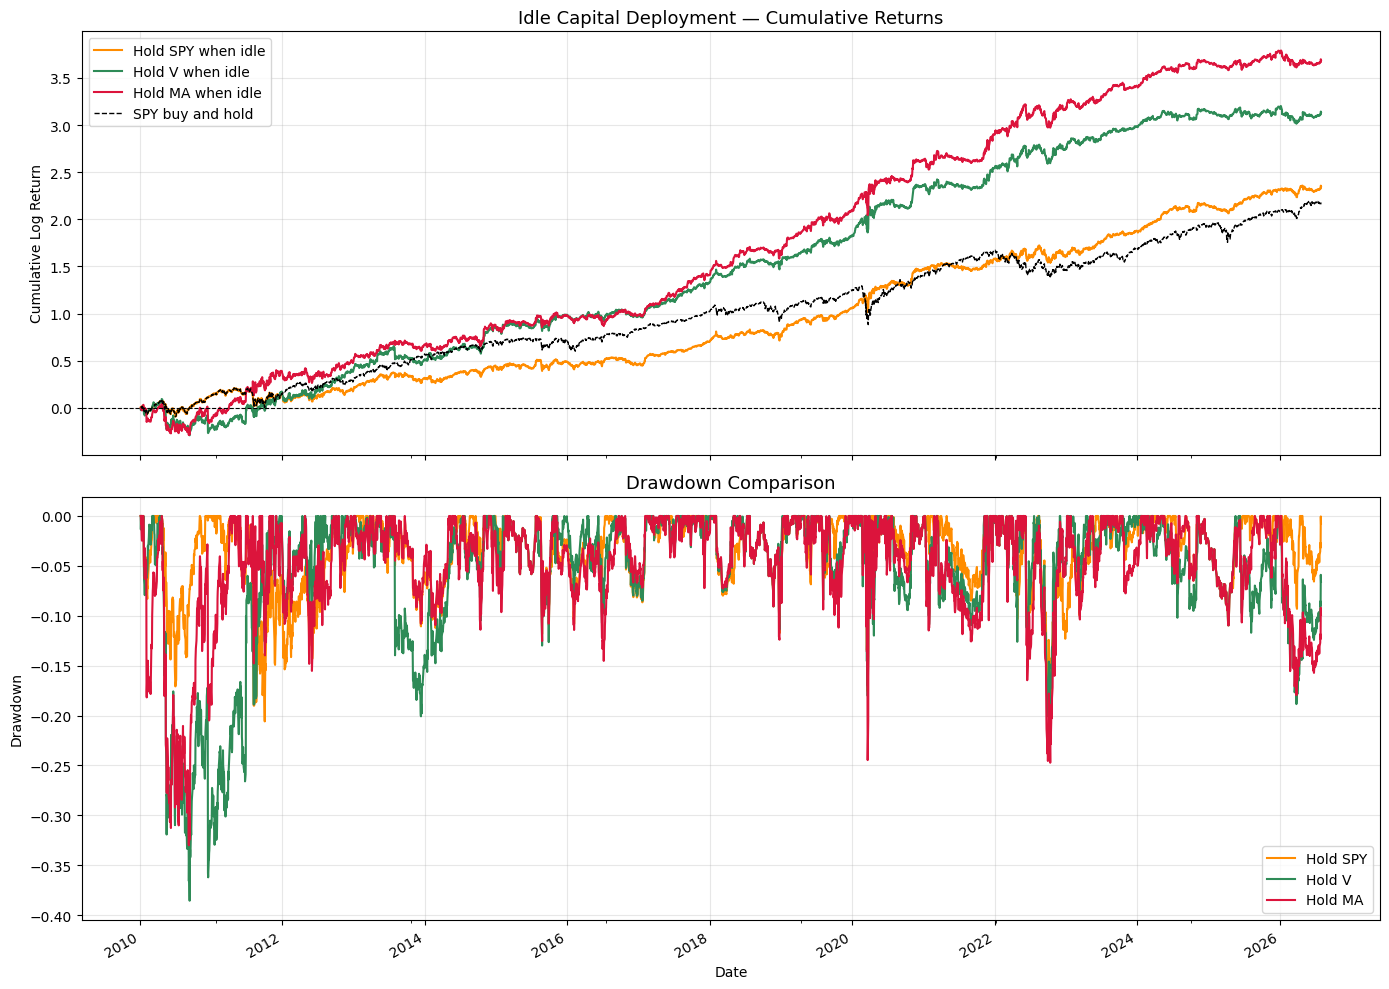

In [19]:
log_returns = np.log(prices / prices.shift(1))

# Pull SPY for comparison
spy_raw = yf.download("SPY", start="2010-01-01", auto_adjust=True)["Close"]
spy_log = np.log(spy_raw / spy_raw.shift(1)).squeeze()
spy_log = spy_log.reindex(binary_returns.index)

# Version 1 - hold SPY when no position
spy_fill_returns = binary_returns.copy()
no_position_days = binary_signals.shift(1) == 0
spy_fill_returns[no_position_days] = spy_log[no_position_days]

# Version 3 - hold V when no position
v_returns = log_returns["V"].reindex(binary_returns.index)
v_fill_returns = binary_returns.copy()
v_fill_returns[no_position_days] = v_returns[no_position_days]

# Version 4 - hold MA when no position
ma_returns = log_returns["MA"].reindex(binary_returns.index)
ma_fill_returns = binary_returns.copy()
ma_fill_returns[no_position_days] = ma_returns[no_position_days]

print("=" * 50)
print("IDLE CAPITAL DEPLOYMENT COMPARISON")
print("=" * 50)
performance_summary(spy_fill_returns.dropna(), "Hold SPY when no signal")
performance_summary(v_fill_returns.dropna(), "Hold V when no signal")
performance_summary(ma_fill_returns.dropna(), "Hold MA when no signal")
performance_summary(spy_log.dropna(), "S&P 500 (SPY) buy and hold")

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

spy_fill_returns.dropna().cumsum().plot(ax=ax1, label="Hold SPY when idle", color="darkorange", linewidth=1.5)
v_fill_returns.dropna().cumsum().plot(ax=ax1, label="Hold V when idle", color="seagreen", linewidth=1.5)
ma_fill_returns.dropna().cumsum().plot(ax=ax1, label="Hold MA when idle", color="crimson", linewidth=1.5)
spy_log.dropna().cumsum().plot(ax=ax1, label="SPY buy and hold", color="black", linewidth=1, linestyle="--")

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Idle Capital Deployment — Cumulative Returns", fontsize=13)
ax1.set_ylabel("Cumulative Log Return")
ax1.legend()
ax1.grid(alpha=0.3)

performance_summary(ma_returns.dropna(), "Hold MA entire period")

# Drawdown
for returns, label, color in [
    (spy_fill_returns.dropna(), "Hold SPY", "darkorange"),
    (v_fill_returns.dropna(), "Hold V", "seagreen"),
    (ma_fill_returns.dropna(), "Hold MA", "crimson"),
]:
    dd = returns.cumsum() - returns.cumsum().cummax()
    dd.plot(ax=ax2, label=label, color=color, linewidth=1.5)

ax2.set_title("Drawdown Comparison", fontsize=13)
ax2.set_ylabel("Drawdown")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()